In [1]:
import numpy as np
import pandas as pd


### (a) Generate a simulated data set as follows:

In [2]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

<h3>In this data set, what is n and what is p? Write out the model
used to generate the data in equation form.

n = 100, p = 1\

$
Y_i = \beta_0 + \beta_1 X_i + \beta_2 X_i^2 + \varepsilon_i
$
\
$
\beta_0 = 0, \quad \beta_1 = 1, \quad \beta_2 = -2, \quad \varepsilon_i \sim N(0, 1).
$

### (b) Create a scatterplot of X against Y . Comment on what you find.

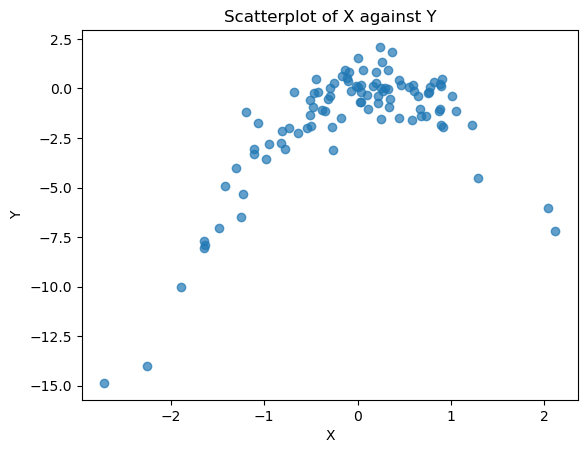

In [3]:
import matplotlib.pyplot as plt

plt.scatter(x, y, alpha=0.7)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatterplot of X against Y")
plt.show()

The scatterplot of X against Y shows a nonlinear relationship and an inverted U shape curve. When x is close to 0, y increases and reaches its maximum value; otherwise, y decreases.

### (c) Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

$
\begin{aligned}
\text{i.} \quad & Y = \beta_0 + \beta_1 X + \varepsilon \\
\text{ii.} \quad & Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon \\
\text{iii.} \quad & Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \varepsilon \\
\text{iv.} \quad & Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \beta_4 X^4 + \varepsilon
\end{aligned}
$

Note you may find it helpful to use the data.frame() function to create a single data set containing both X and Y .

In [4]:
data = pd.DataFrame({'X': x, 'Y': y})
data.head()

,X,Y
0,0.345584,-0.544554
1,0.821618,0.333950
2,0.330437,-0.013532
3,-1.303157,-4.030442
4,0.905356,0.484861


In [5]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import numpy as np

def loocv_error(x, y, degree):
    loo = LeaveOneOut()
    errors = []
    poly = PolynomialFeatures(degree=degree, include_bias=True)

    for train_idx, test_idx in loo.split(x):
        X_train, X_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model = LinearRegression().fit(X_train_poly, y_train)
        y_pred = model.predict(X_test_poly)

        errors.append((y_test - y_pred) ** 2)

    return np.mean(errors)

In [6]:
X = data[['X']].values
Y = data['Y'].values

for d in range(1, 5):
    error = loocv_error(X, Y, degree=d)
    print(f"Model {d} — LOOCV MSE: {error:.4f}")

Model 1 — LOOCV MSE: 6.6330
Model 2 — LOOCV MSE: 1.1229
Model 3 — LOOCV MSE: 1.3018
Model 4 — LOOCV MSE: 1.3324


### (d) Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?

In [7]:
rng2 = np.random.default_rng(42)
x = rng2.normal(size=100)
y = x - 2 * x**2 + rng2.normal(size=100)

In [8]:
data = pd.DataFrame({'X': x, 'Y': y})
data.head()

,X,Y
0,0.304717,-0.259150
1,-1.039984,-1.903890
2,0.750451,-0.732167
3,0.940565,-0.091244
4,-1.951035,-10.497729


In [9]:
X = data[['X']].values
Y = data['Y'].values

for d in range(1, 5):
    error = loocv_error(X, Y, degree=d)
    print(f"Model {d} — LOOCV MSE: {error:.4f}")

Model 1 — LOOCV MSE: 4.2519
Model 2 — LOOCV MSE: 0.9640
Model 3 — LOOCV MSE: 0.9913
Model 4 — LOOCV MSE: 1.0182


because we use new random seed we will got a new dataset(new x,y and error). we still find the same result that Model 2 got the lowest LOOCV MSE.

### (e) Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.

Model 2: $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon $ had the smallest LOOCV error.\
because these data are generated by an underlying quadratic model. Model 1 cannot capture the polynomial relationship of the data, resulting in a higher LOOCV MSE. Models 3 & 4 exhibit overfitting the noise, resulting in higher LOOCV MSEs compared to Model 2.

### (f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?

In [10]:
import numpy as np, pandas as pd, statsmodels.api as sm
from statsmodels.formula.api import ols

rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2*x**2 + rng.normal(size=100)
df = pd.DataFrame({'X': x, 'Y': y})

mods = {
    1: 'Y ~ X',
    2: 'Y ~ X + I(X**2)',
    3: 'Y ~ X + I(X**2) + I(X**3)',
    4: 'Y ~ X + I(X**2) + I(X**3) + I(X**4)'
}
results = {d: ols(formula, data=df).fit() for d, formula in mods.items()}

for d, res in results.items():
    print(f'Model {d}')
    print(res.summary().tables[1]) 

Model 1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4650      0.247     -5.937      0.000      -1.955      -0.975
X              1.9494      0.289      6.752      0.000       1.376       2.522
Model 2
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0728      0.119     -0.611      0.543      -0.309       0.164
X              0.9663      0.126      7.647      0.000       0.715       1.217
I(X ** 2)     -2.0047      0.091    -22.072      0.000      -2.185      -1.824
Model 3
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0572      0.120     -0.477      0.635      -0.295       0.181
X              1.1146      0

model 1: x has a significant positive relationship, but The intercept is significantly negative and coeffcient is -1.465. model 2: both x and x^2 are highly significant, the coeffcient of intercept, x, and x^2 specifically is -0.0728, 0.9663, -2.0047, they are approximately equal to (a) -> $\beta_0 = 0, \quad \beta_1 = 1, \quad \beta_2 = -2 $. mdoel 3: x^3 is not significant, but x & x^2 are still significant, showing no more explanatory power. model 4: x^3 is not significant, x^4 slightly significant, the coeffcient of x^3 and x^4 are very small.